# **Project Name**    -  Food Waste Management Analysis



##### **Project Type**    - Exploratory Data Analysis (EDA)
##### **Contribution**    - Individual

# **Project Summary -**

# **GitHub Link -**    - https://github.com/namratakam2004/Food_Waste_Managemen

# **Problem Statement**


**Here**

#### **Define Your Business Objective?**

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
from sqlalchemy import create_engine
import psycopg2
import matplotlib.pyplot as plt

### Dataset Loading

In [ ]:
# Load Dataset


Dataset loaded successfully


### Dataset First View

In [3]:
# Dataset First Look
df.head(10)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47
5,3879,Airport,1.0,Trip Completed,13-07-2016 21:57:28,13-07-2016 22:28:59
6,4270,Airport,1.0,Trip Completed,14-07-2016 06:15:32,14-07-2016 07:13:15
7,5510,Airport,1.0,Trip Completed,15-07-2016 05:11:52,15-07-2016 06:07:52
8,6248,City,1.0,Trip Completed,15-07-2016 17:57:27,15-07-2016 18:50:51
9,267,City,2.0,Trip Completed,11/7/2016 6:46,11/7/2016 7:25


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
total_rows = len(df.index)
total_columns = len(df.columns)
print(f"Total Rows: {total_rows}")
print(f"Total Columns: {total_columns}")

Total Rows: 6745
Total Columns: 6


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 316.3 KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicates = df.duplicated().sum()
print(f"Total duplicate values: {duplicates}")

Total duplicate values: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
nulls = df.isnull().sum()
print(f"Total null values: {nulls}")

Total null values: Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64


In [8]:
# Visualizing the missing values
df.isnull()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
6740,False,False,True,False,False,True
6741,False,False,True,False,False,True
6742,False,False,True,False,False,True
6743,False,False,True,False,False,True


### What did you know about your dataset?

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='str')

In [10]:
# Dataset Describe
df.describe()

,Request id,Driver id
count,6745.000000,4095.000000
mean,3384.644922,149.501343
std,1955.099667,86.051994
min,1.000000,1.000000
25%,1691.000000,75.000000
50%,3387.000000,149.000000
75%,5080.000000,224.000000
max,6766.000000,300.000000


### Variables Description

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(col, ":", df[col].nunique())

Request id : 6745
Pickup point : 2
Driver id : 300
Status : 3
Request timestamp : 5618
Drop timestamp : 2598


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Convert Driver ID to integer while keeping missing values
df['Driver id'] = df['Driver id'].astype('Int64')

# Convert timestamp columns to datetime format
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], dayfirst=True, format='mixed', errors='coerce')
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'], dayfirst=True, format='mixed', errors='coerce')

# Extract request date and request time
df['Request_date'] = df['Request timestamp'].dt.date
df['Request_time'] = df['Request timestamp'].dt.time

# Convert request date to datetime format
df['Request_date'] = pd.to_datetime(df['Request timestamp'].dt.date)

# Extract hour from request timestamp
df['Hour'] = df['Request timestamp'].dt.hour

# Extract weekday name
df['Weekday'] = df['Request timestamp'].dt.day_name()

# Calculate trip duration in minutes
df['trip_duration_min'] = (df['Drop timestamp'] - df['Request timestamp']).dt.total_seconds()/60

# Round trip duration to one decimal place
df['trip_duration_min'] = df['trip_duration_min'].round(1)

# Create driver assigned flag (1 = assigned, 0 = not assigned)
df['driver_assigned'] = df['Driver id'].notna().astype('int')

# Function to categorize requests into time slots
def get_time_slot(hour):
    if 0 <= hour < 5:
        return 'Early Morning'
    elif 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# Create time slot column    
df['time_slot'] = df['Hour'].apply(get_time_slot)

# Standardize column names for SQL compatibility
df.columns = [
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ','_')  
]

# Remove tuple formatting from column names
df.columns = [col[0] if isinstance(col,tuple)else col for col in df.columns]
for col in df.columns:
    print(col, type(col))

# Save cleaned dataset
clean_data = df
clean_data.to_csv('data/clean_uber_requests_data.csv', index=False)

request_id <class 'str'>
pickup_point <class 'str'>
driver_id <class 'str'>
status <class 'str'>
request_timestamp <class 'str'>
drop_timestamp <class 'str'>
request_date <class 'str'>
request_time <class 'str'>
hour <class 'str'>
weekday <class 'str'>
trip_duration_min <class 'str'>
driver_assigned <class 'str'>
time_slot <class 'str'>


### What all manipulations have you done and insights you found?

## 4. ***Data Loading***

In [13]:
# PostgreSQL database credentials
db_host = 'localhost'
db_name = 'postgres'
db_password ='system'
db_user ='postgres'
db_port = 5432

# Create database connection
try:
    engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")
    print("Database Connection Successful")
except Exception as e:
    print(f"Database Connection Failed: {e}")

# Upload cleaned data to PostgreSQL table
clean_data.to_sql(name='uber_request_analysis', con=engine, index=False, if_exists='replace')

Database Connection Successful


745

## ***5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

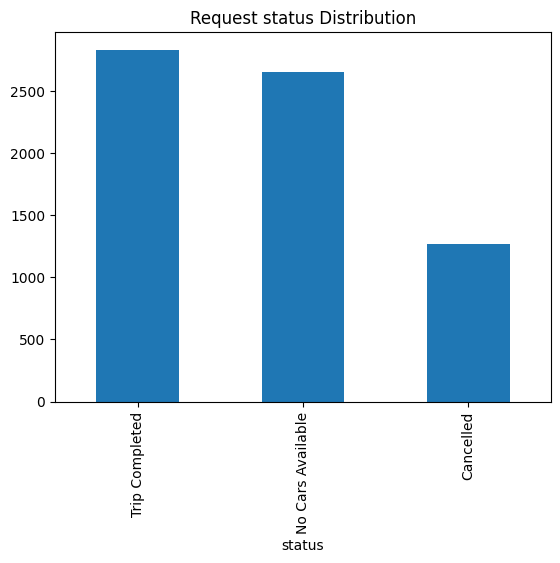

In [ ]:
# request status distribution


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 2

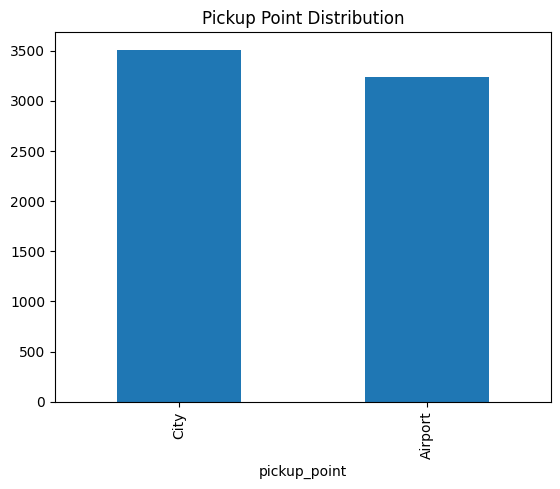

In [ ]:
# pickup point distribution


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 3

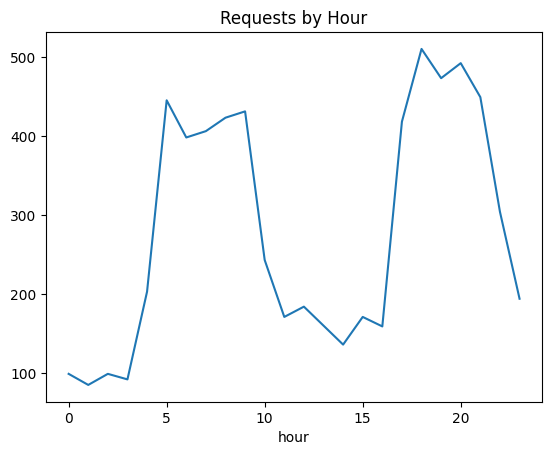

In [ ]:
#requests by hour


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 4

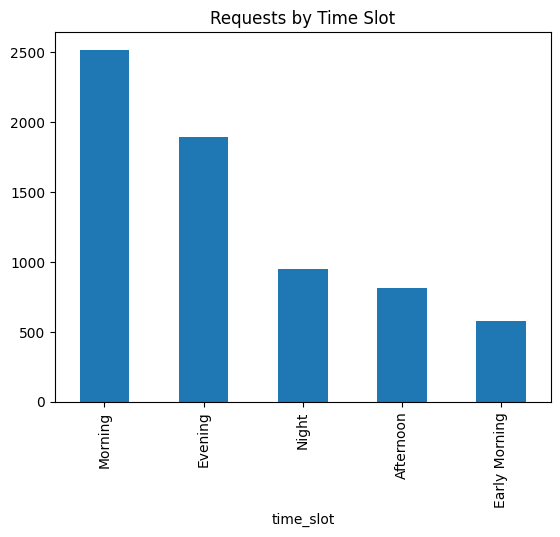

In [ ]:
#requests by time slot


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 5

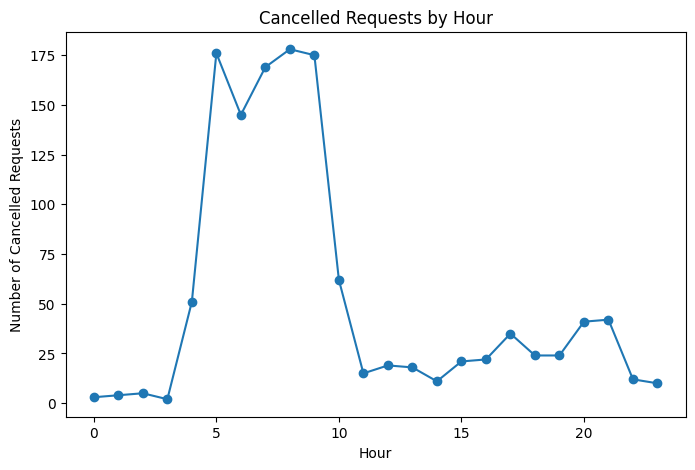

In [ ]:
# cancellation by hour


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 6

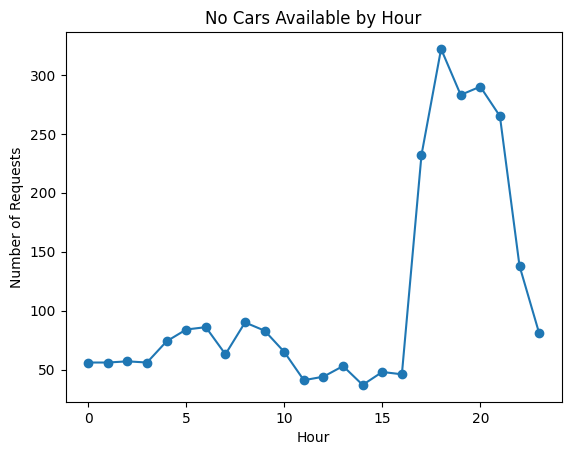

In [ ]:
#no cars available by hour


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights can help Uber increase driver availability during shortage periods.
This chart clearly points to a negative growth factor. When customers cannot find available cars, Uber loses potential revenue and customers may choose alternative transportation options. Repeated occurrences can damage customer loyalty.

#### Chart - 7

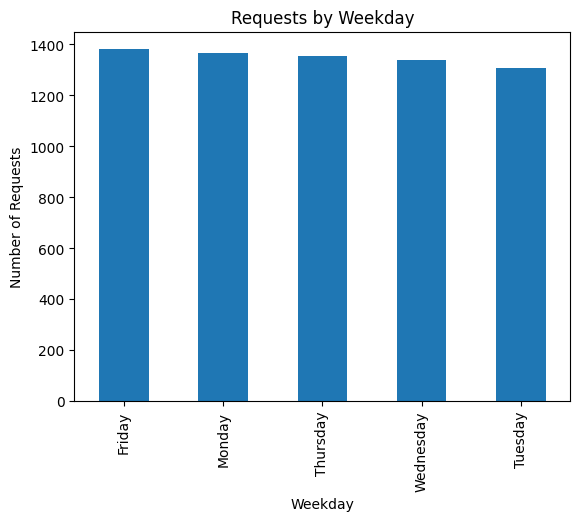

In [ ]:
# requests by weekdays


##### 1. Why did you pick the specific chart?

I chose this chart to understand how ride demand changes across different days of the week.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some weekdays receive more ride requests than others, indicating variations in customer demand throughout the week.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Uber can plan driver schedules based on demand patterns across the week.
A negative insight may arise if certain weekdays consistently experience high demand but inadequate driver supply. This can increase cancellations and reduce service quality on those days.

#### Chart - 8

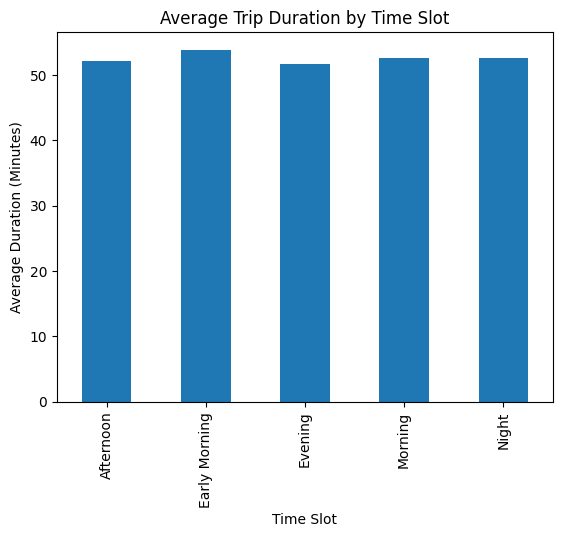

In [ ]:
# average trip duration by time slot


##### 1. Why did you pick the specific chart?

I selected this chart to analyze how trip duration varies across different time slots.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that average trip duration is not the same across all time slots. Some periods have longer trips compared to others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding trip duration patterns helps improve driver planning and operational efficiency.
A potential negative insight is that longer trip durations during certain time slots may reduce driver availability for new requests. This can contribute to higher waiting times and more "No Cars Available" cases during busy periods.

#### Chart - 9

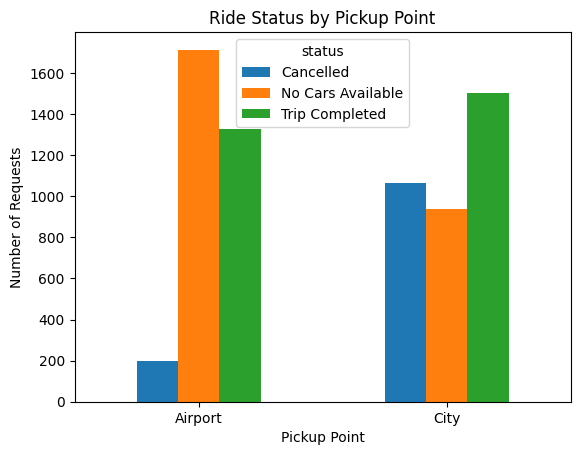

In [ ]:
#

##### 1. Why did you pick the specific chart?

I chose this chart to compare ride outcomes across different pickup locations and understand whether service performance varies between the Airport and the City.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how completed trips, cancellations, and no-car-availability cases are distributed at each pickup point. One pickup location may experience more service issues than the other.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights can help Uber allocate drivers more effectively at locations with higher service issues.
A negative insight is that if a pickup point consistently experiences high cancellations or no-car-availability cases, customers at that location may face poor service and become less likely to use the platform.

#### Chart - 10

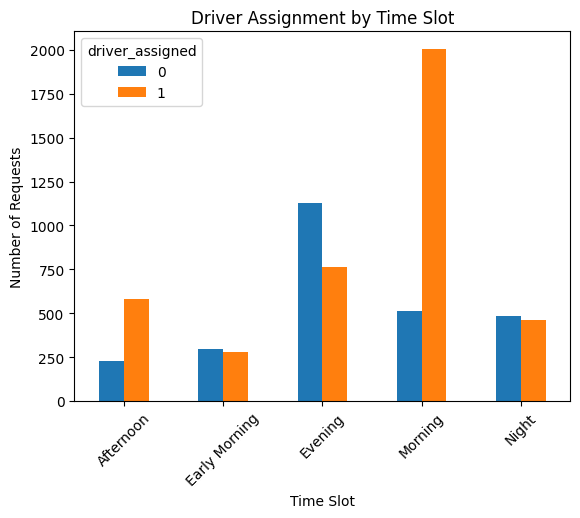

In [ ]:
#

##### 1. Why did you pick the specific chart?

I selected this chart to understand whether driver assignment rates vary across different times of the day.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some time slots have more unassigned requests than others, indicating periods where driver availability is limited.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights can help Uber identify time periods where additional drivers are needed.
A negative insight is that higher numbers of unassigned requests indicate unmet customer demand, which may lead to customer dissatisfaction and lost revenue.

#### Chart - 11

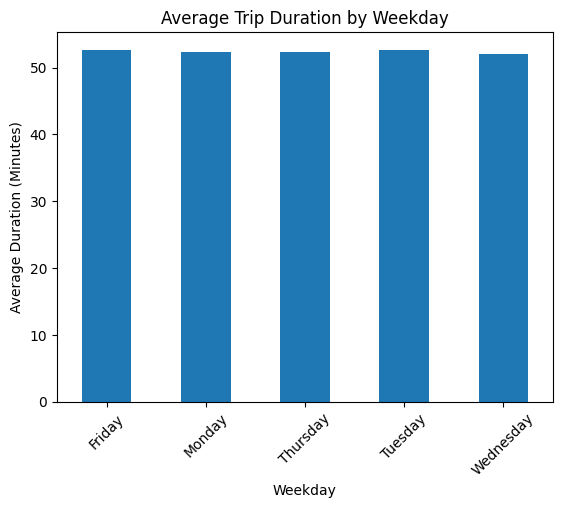

In [ ]:
#

##### 1. Why did you pick the specific chart?

I chose this chart to understand whether trip durations vary across different days of the week.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that average trip duration differs across weekdays, indicating changes in travel patterns and traffic conditions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding trip duration trends can help improve driver planning and resource allocation.
A negative insight is that longer average trip durations may reduce driver availability for new requests, which can contribute to delays and unfulfilled ride requests during busy periods.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Recommendations

Based on the analysis, the following actions are recommended:

1. Increase driver availability during peak demand hours, especially in the morning and evening.
2. Improve driver allocation at locations with high ride demand to reduce unfulfilled requests.
3. Implement incentive programs to encourage more drivers to operate during busy periods.
4. Monitor cancellation patterns and take measures to reduce frequent cancellations.
5. Use demand forecasting to better match driver supply with customer demand.

These actions can help increase trip completion rates, reduce customer wait times, and improve overall customer satisfaction.

# **Conclusion**


This project analyzed Uber ride request data to understand customer demand patterns and identify reasons for unsuccessful trips. The analysis showed that ride requests are highest during specific time periods, particularly in the morning and evening. A significant number of requests were either cancelled or could not be fulfilled due to the unavailability of cars.

By analyzing ride status, pickup locations, and demand trends, several supply-demand gaps were identified. The findings suggest that improving driver availability during peak hours and high-demand locations can help reduce cancellations and increase trip completion rates.

Overall, the project demonstrates how data analysis can be used to identify operational challenges and support better business decisions, ultimately improving customer satisfaction and service efficiency.